**Week 6 Jupyter Notebook**

Decision Trees and Random Forests

**Integrated Capstone Project:** Credit Risk Prediction

**Objective**

The objective of this notebook is to develop Decision Tree and Random Forest classification models to predict loan default using borrower demographic and financial characteristics. The models will be compared based on accuracy, precision, recall, F1-score, ROC-AUC, and feature importance to determine which approach provides better predictive performance for credit risk assessment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
# Load Cleaned Dataset

credit_risk = pd.read_csv("credit_risk_cleaned.csv")

credit_risk.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Select Features

features = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

X = credit_risk[features]

y = credit_risk['loan_status']

In [4]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
# Decision Tree Model

tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree.fit(
    X_train,
    y_train
)

tree_pred = tree.predict(
    X_test
)

print(classification_report(
    y_test,
    tree_pred
))

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        tree_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5066
           1       0.75      0.57      0.65      1418

    accuracy                           0.87      6484
   macro avg       0.82      0.76      0.78      6484
weighted avg       0.86      0.87      0.86      6484

Accuracy: 0.865823565700185


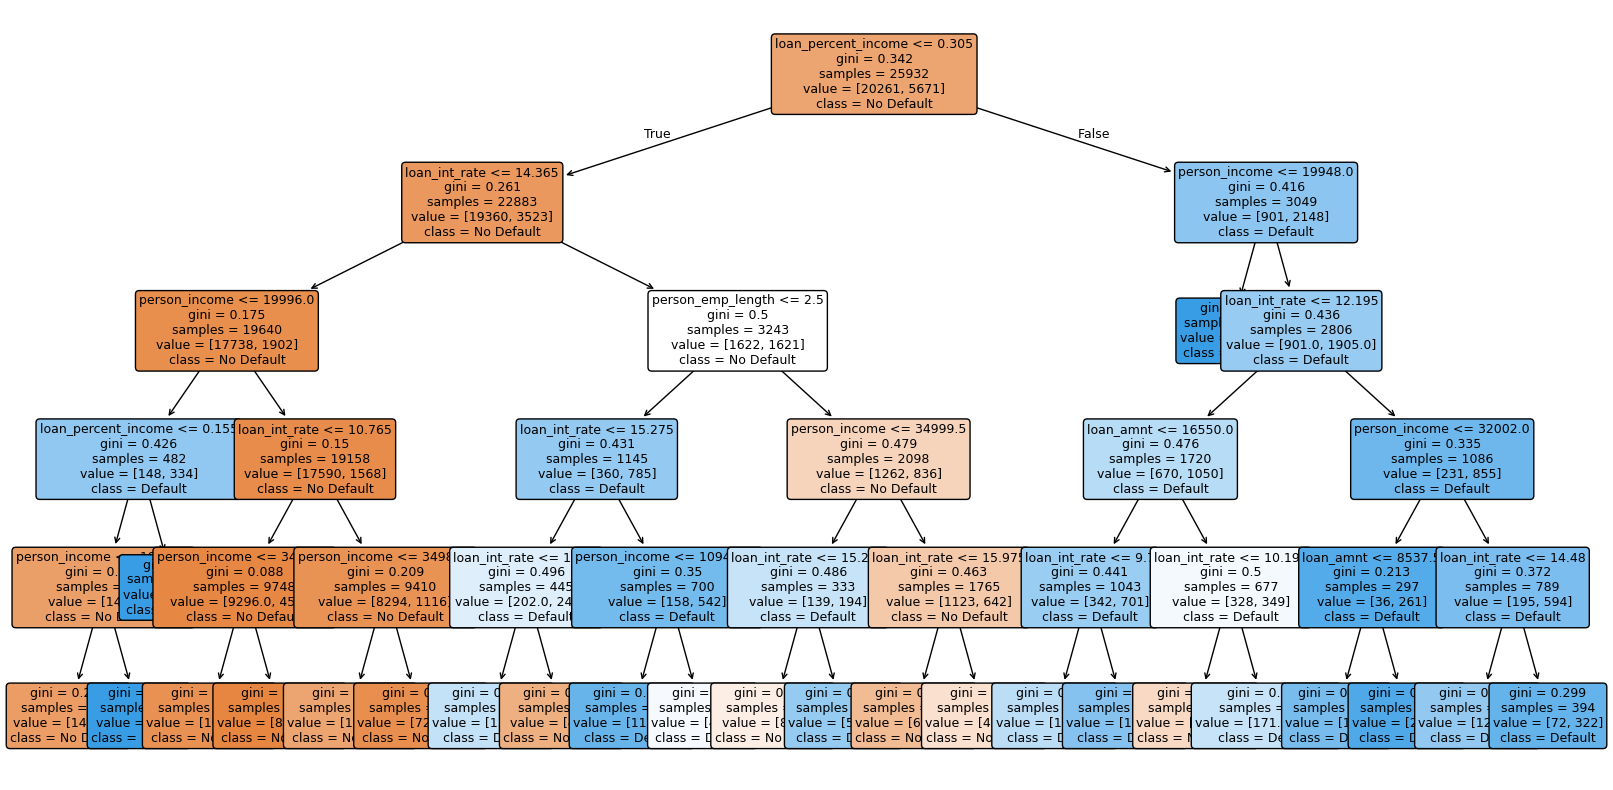

In [6]:
# Plot Decision Tree

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=features,
    class_names=['No Default','Default'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.show()

In [7]:
# Random Forest Model

forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

forest.fit(
    X_train,
    y_train
)

forest_pred = forest.predict(
    X_test
)

print(classification_report(
    y_test,
    forest_pred
))

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        forest_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5066
           1       0.77      0.57      0.66      1418

    accuracy                           0.87      6484
   macro avg       0.83      0.76      0.79      6484
weighted avg       0.86      0.87      0.86      6484

Accuracy: 0.8696792103639729


In [8]:
# Compare Decision Tree and Random Forest

comparison = pd.DataFrame({

    'Model':[
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy':[

        accuracy_score(
            y_test,
            tree_pred
        ),

        accuracy_score(
            y_test,
            forest_pred
        )
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.865824
1,Random Forest,0.869679


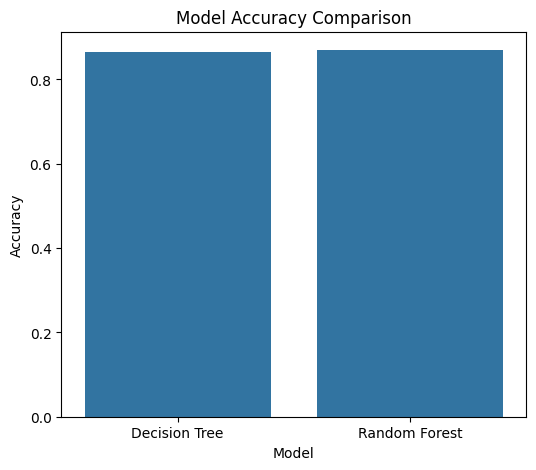

In [9]:
# Plot Model Comparison

plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.title("Model Accuracy Comparison")

plt.show()

In [10]:
# Random Forest Feature Importance

importance = pd.DataFrame({

    'Feature':features,

    'Importance':forest.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                      Feature  Importance
5         loan_percent_income    0.386657
4               loan_int_rate    0.280711
1               person_income    0.208114
3                   loan_amnt    0.067204
2           person_emp_length    0.033872
0                  person_age    0.013375
6  cb_person_cred_hist_length    0.010067


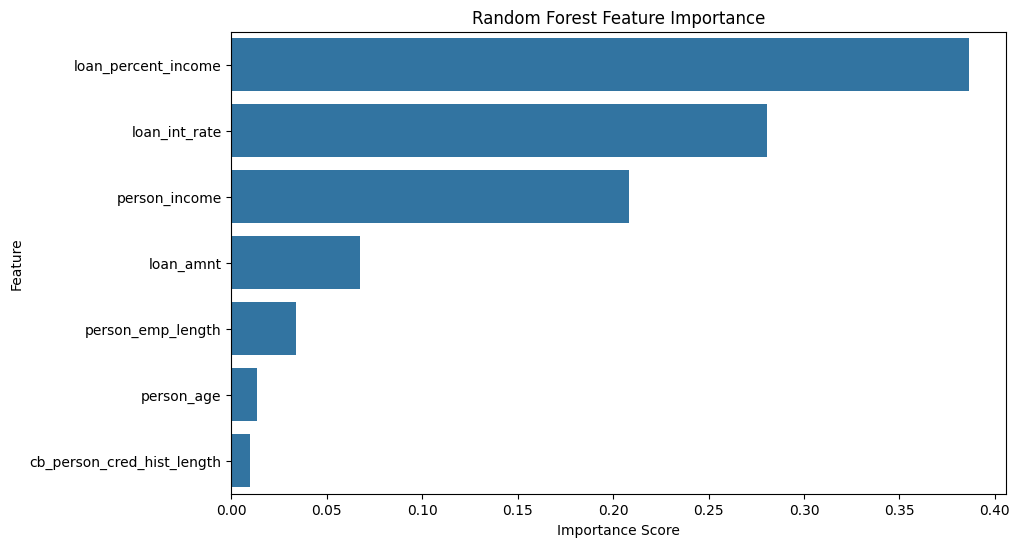

In [11]:
# Feature Importance Plot

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.show()

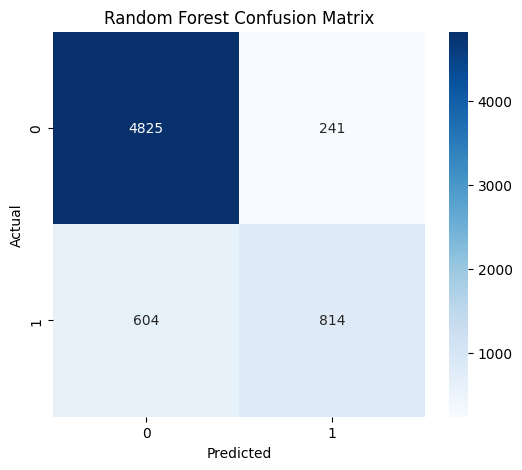

In [12]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    forest_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

ROC-AUC: 0.8765244471147288


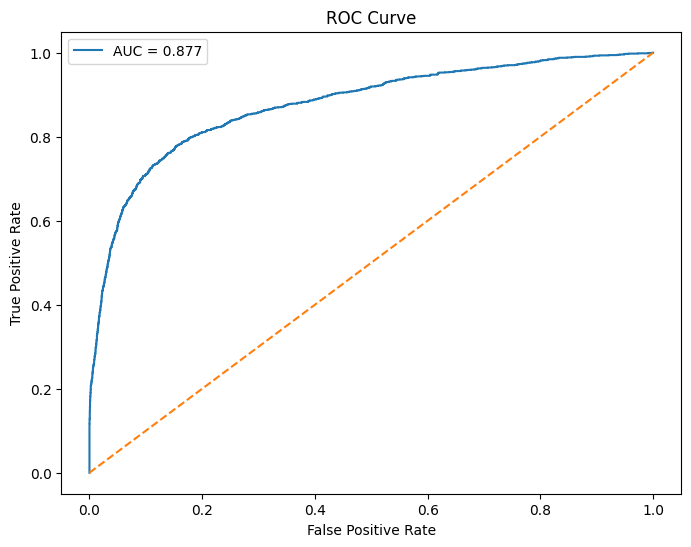

In [13]:
# ROC Curve

prob = forest.predict_proba(
    X_test
)[:,1]

auc = roc_auc_score(
    y_test,
    prob
)

print("ROC-AUC:", auc)

fpr, tpr, _ = roc_curve(
    y_test,
    prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

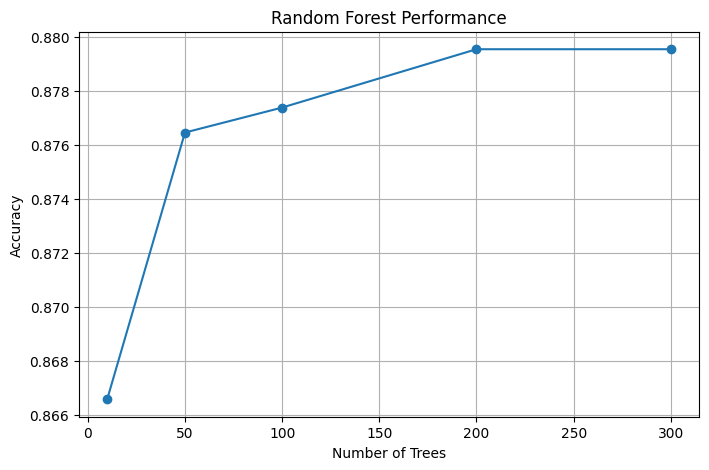

In [14]:
# Effect of Number of Trees

trees = [10,50,100,200,300]

scores = []

for n in trees:

    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    rf.fit(
        X_train,
        y_train
    )

    pred = rf.predict(
        X_test
    )

    scores.append(
        accuracy_score(
            y_test,
            pred
        )
    )

plt.figure(figsize=(8,5))

plt.plot(
    trees,
    scores,
    marker='o'
)

plt.xlabel("Number of Trees")

plt.ylabel("Accuracy")

plt.title("Random Forest Performance")

plt.grid(True)

plt.show()

**Conclusion**

The objective of Week 6 was to compare Decision Tree and Random Forest classifiers for predicting loan default and to evaluate the contribution of individual borrower characteristics through feature importance analysis. Both models demonstrated strong predictive performance, with the Random Forest model providing slightly higher accuracy and greater robustness than the single Decision Tree.

The Decision Tree classifier achieved an overall accuracy of 86.58%, with a precision of 0.75, recall of 0.57, and an F1-score of 0.65 for the default class. The model correctly identified most non-default borrowers (precision = 0.89, recall = 0.95) while also providing reasonable performance in detecting defaulting borrowers.

The Random Forest classifier slightly outperformed the Decision Tree, achieving an accuracy of 86.97%, with a precision of 0.77, recall of 0.57, and an F1-score of 0.66 for the default class. Although the improvement in overall accuracy was modest, the Random Forest provided better precision and overall stability by combining predictions from multiple decision trees, thereby reducing overfitting and improving generalization.

Feature importance analysis revealed that loan_percent_income was the most influential predictor, with an importance score of 0.3867, followed by loan_int_rate (0.2807) and person_income (0.2081). These three variables accounted for the majority of the model's predictive power, indicating that a borrower's debt burden, borrowing cost, and income level are the primary factors influencing loan default risk. Loan amount contributed moderately (0.0672), while employment length (0.0339), age (0.0134), and credit history length (0.0101) had comparatively smaller effects.

The Random Forest model also achieved a ROC-AUC of 0.8765, indicating excellent discrimination between default and non-default borrowers. This strong AUC value demonstrates that the model is highly effective at ranking borrowers according to their likelihood of default, making it well suited for credit risk assessment.

Overall, the Week 6 results demonstrate that Random Forest is the superior model for this dataset. By aggregating predictions from multiple decision trees, it achieved higher predictive accuracy, greater robustness, and stronger discrimination than a single Decision Tree. Furthermore, the feature importance analysis confirms that loan percent income, interest rate, and borrower income are the dominant factors driving default risk. These findings support the use of ensemble learning methods for credit risk prediction and provide a strong foundation for implementing more advanced machine learning models in subsequent stages of the capstone project.